In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io

In [3]:
# Step 2: Load the dataset
data = pd.read_csv('jharkhand_route_safety_dataset_4000_with_cities.csv')

In [4]:
data

,latitude,longitude,location_name,lat_bin,lon_bin,severity,is_lit,crowd_density,crime_rate,accident_rate,date_time,hour,is_night,safety_score,safety_class
0,23.110890,85.831181,"Sector, Jamshedpur",23.11,85.83,Medium,No,High,2.001418,2.153324,2024-12-07 10:19:00,10,0,0.306716,Unsafe
1,25.127500,86.904989,"Chowk, Deoghar",25.13,86.90,Medium,Yes,High,5.380110,2.257778,2024-09-14 17:15:00,17,0,0.588329,Moderate
2,24.361979,86.696740,"Colony, Deoghar",24.36,86.70,High,Yes,Medium,2.258188,5.375759,2024-02-14 12:08:00,12,0,0.240066,Unsafe
3,23.895305,83.907940,"Sector, Daltonganj",23.90,83.91,Low,No,High,1.040094,1.302531,2024-09-25 18:38:00,18,0,0.629253,Moderate
4,22.346065,83.886548,"Market Street, Gumla",22.35,83.89,Medium,Yes,Low,1.863361,2.755286,2024-11-06 16:39:00,16,0,0.433786,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,23.347375,84.456534,"Bazaar, Gumla",23.35,84.46,High,Yes,Low,0.770372,0.515342,2024-01-21 02:52:00,2,1,0.310147,Unsafe
3996,22.970404,84.163788,"Chowk, Gumla",22.97,84.16,Low,No,High,2.265650,2.143507,2024-11-15 15:41:00,15,0,0.667756,Moderate
3997,23.181003,85.294512,"Station Road, Ranchi",23.18,85.29,Medium,No,Medium,3.636189,2.908934,2024-08-07 19:04:00,19,0,0.415624,Moderate
3998,23.654792,87.378813,"Village Road, Dumka",23.65,87.38,Low,No,Medium,3.595246,4.835267,2024-07-05 12:11:00,12,0,0.373445,Unsafe


In [5]:
# Step 3: Clean the data
# Convert date_time to datetime format
data['date_time'] = pd.to_datetime(data['date_time'])

In [6]:
data

,latitude,longitude,location_name,lat_bin,lon_bin,severity,is_lit,crowd_density,crime_rate,accident_rate,date_time,hour,is_night,safety_score,safety_class
0,23.110890,85.831181,"Sector, Jamshedpur",23.11,85.83,Medium,No,High,2.001418,2.153324,2024-12-07 10:19:00,10,0,0.306716,Unsafe
1,25.127500,86.904989,"Chowk, Deoghar",25.13,86.90,Medium,Yes,High,5.380110,2.257778,2024-09-14 17:15:00,17,0,0.588329,Moderate
2,24.361979,86.696740,"Colony, Deoghar",24.36,86.70,High,Yes,Medium,2.258188,5.375759,2024-02-14 12:08:00,12,0,0.240066,Unsafe
3,23.895305,83.907940,"Sector, Daltonganj",23.90,83.91,Low,No,High,1.040094,1.302531,2024-09-25 18:38:00,18,0,0.629253,Moderate
4,22.346065,83.886548,"Market Street, Gumla",22.35,83.89,Medium,Yes,Low,1.863361,2.755286,2024-11-06 16:39:00,16,0,0.433786,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,23.347375,84.456534,"Bazaar, Gumla",23.35,84.46,High,Yes,Low,0.770372,0.515342,2024-01-21 02:52:00,2,1,0.310147,Unsafe
3996,22.970404,84.163788,"Chowk, Gumla",22.97,84.16,Low,No,High,2.265650,2.143507,2024-11-15 15:41:00,15,0,0.667756,Moderate
3997,23.181003,85.294512,"Station Road, Ranchi",23.18,85.29,Medium,No,Medium,3.636189,2.908934,2024-08-07 19:04:00,19,0,0.415624,Moderate
3998,23.654792,87.378813,"Village Road, Dumka",23.65,87.38,Low,No,Medium,3.595246,4.835267,2024-07-05 12:11:00,12,0,0.373445,Unsafe


In [7]:
# Extract city from location_name (e.g., "Sector, Jamshedpur" -> "Jamshedpur")
data['city'] = data['location_name'].str.split(', ').str[-1]

In [8]:
data

,latitude,longitude,location_name,lat_bin,lon_bin,severity,is_lit,crowd_density,crime_rate,accident_rate,date_time,hour,is_night,safety_score,safety_class,city
0,23.110890,85.831181,"Sector, Jamshedpur",23.11,85.83,Medium,No,High,2.001418,2.153324,2024-12-07 10:19:00,10,0,0.306716,Unsafe,Jamshedpur
1,25.127500,86.904989,"Chowk, Deoghar",25.13,86.90,Medium,Yes,High,5.380110,2.257778,2024-09-14 17:15:00,17,0,0.588329,Moderate,Deoghar
2,24.361979,86.696740,"Colony, Deoghar",24.36,86.70,High,Yes,Medium,2.258188,5.375759,2024-02-14 12:08:00,12,0,0.240066,Unsafe,Deoghar
3,23.895305,83.907940,"Sector, Daltonganj",23.90,83.91,Low,No,High,1.040094,1.302531,2024-09-25 18:38:00,18,0,0.629253,Moderate,Daltonganj
4,22.346065,83.886548,"Market Street, Gumla",22.35,83.89,Medium,Yes,Low,1.863361,2.755286,2024-11-06 16:39:00,16,0,0.433786,Moderate,Gumla
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,23.347375,84.456534,"Bazaar, Gumla",23.35,84.46,High,Yes,Low,0.770372,0.515342,2024-01-21 02:52:00,2,1,0.310147,Unsafe,Gumla
3996,22.970404,84.163788,"Chowk, Gumla",22.97,84.16,Low,No,High,2.265650,2.143507,2024-11-15 15:41:00,15,0,0.667756,Moderate,Gumla
3997,23.181003,85.294512,"Station Road, Ranchi",23.18,85.29,Medium,No,Medium,3.636189,2.908934,2024-08-07 19:04:00,19,0,0.415624,Moderate,Ranchi
3998,23.654792,87.378813,"Village Road, Dumka",23.65,87.38,Low,No,Medium,3.595246,4.835267,2024-07-05 12:11:00,12,0,0.373445,Unsafe,Dumka


In [9]:
# Check for missing values and handle them (if any)
data = data.dropna()

In [10]:
# Step 4: Exploratory Data Analysis
# 4.1: Average safety score by city
city_safety = data.groupby('city')['safety_score'].mean().sort_values()

In [11]:
# 4.2: Safety score by hour of the day
hourly_safety = data.groupby('hour')['safety_score'].mean()

In [12]:
# 4.3: Crime and accident rates by safety class
safety_class_stats = data.groupby('safety_class')[['crime_rate', 'accident_rate']].mean()

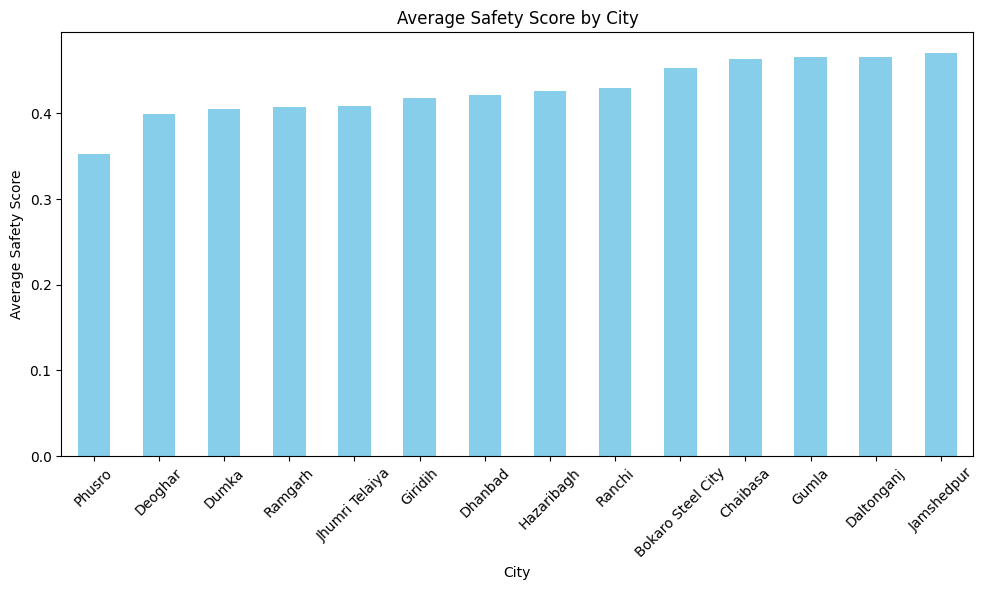

In [13]:
# Step 5: Visualizations
# 5.1: Bar chart - Average safety score by city
plt.figure(figsize=(10, 6))
city_safety.plot(kind='bar', color='skyblue')
plt.title('Average Safety Score by City')
plt.xlabel('City')
plt.ylabel('Average Safety Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('city_safety_score.png')

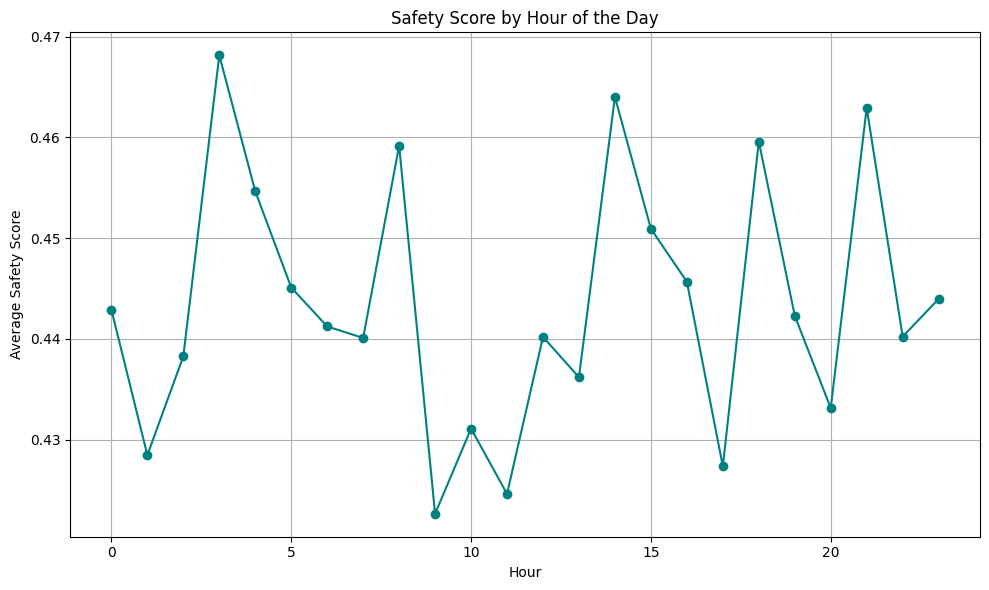

In [14]:
# 5.2: Line chart - Safety score by hour
plt.figure(figsize=(10, 6))
hourly_safety.plot(kind='line', marker='o', color='teal')
plt.title('Safety Score by Hour of the Day')
plt.xlabel('Hour')
plt.ylabel('Average Safety Score')
plt.grid(True)
plt.tight_layout()
plt.savefig('hourly_safety_score.png')

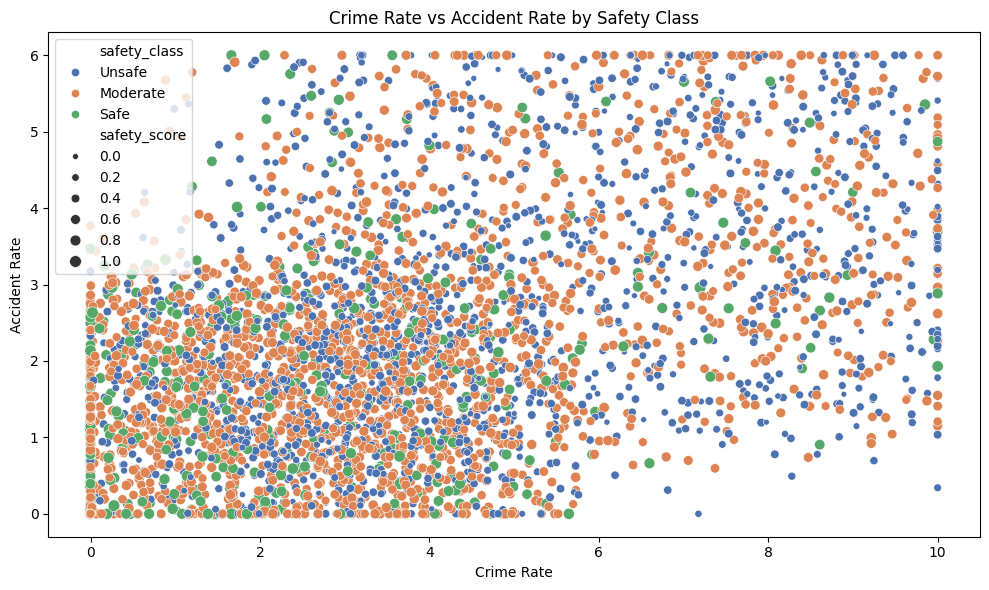

In [15]:
# 5.3: Scatter plot - Crime rate vs Accident rate by safety class
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='crime_rate', y='accident_rate', hue='safety_class', palette='deep', size='safety_score')
plt.title('Crime Rate vs Accident Rate by Safety Class')
plt.xlabel('Crime Rate')
plt.ylabel('Accident Rate')
plt.tight_layout()
plt.savefig('crime_vs_accident.png')

In [16]:
# Step 6: New Analysis - Distribution of safety_class across crowd_density
# 6.1: Group by crowd_density and safety_class to get counts
crowd_safety_dist = data.groupby(['crowd_density', 'safety_class']).size().unstack(fill_value=0)

<Figure size 1000x600 with 0 Axes>

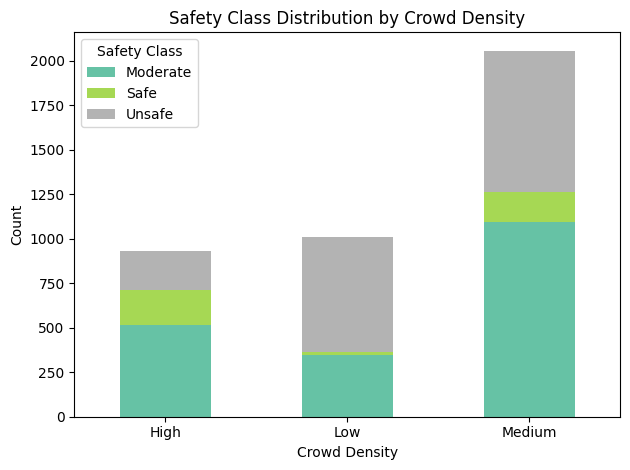

In [17]:
# 6.2: Stacked bar chart - Safety class distribution by crowd_density
plt.figure(figsize=(10, 6))
crowd_safety_dist.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Safety Class Distribution by Crowd Density')
plt.xlabel('Crowd Density')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Safety Class')
plt.tight_layout()
plt.savefig('crowd_safety_distribution.png')

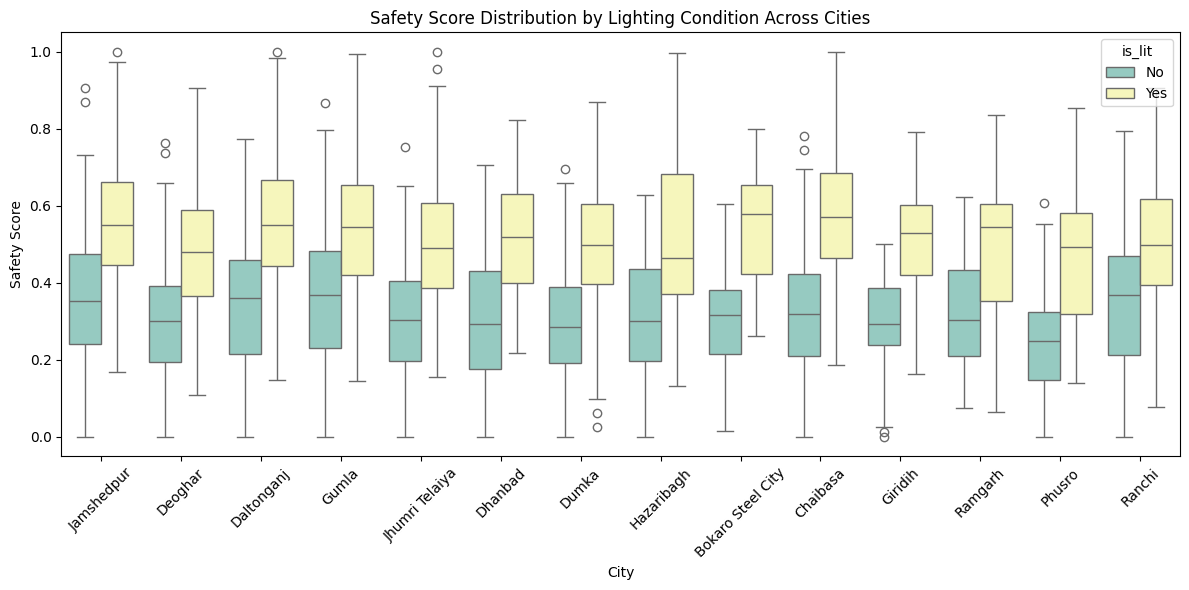

In [18]:
# Step 7: New Analysis - Impact of lighting (is_lit) on safety_score across cities
# 7.1: Box plot - Safety score by is_lit across cities
plt.figure(figsize=(12, 6))
sns.boxplot(data=data, x='city', y='safety_score', hue='is_lit', palette='Set3')
plt.title('Safety Score Distribution by Lighting Condition Across Cities')
plt.xlabel('City')
plt.ylabel('Safety Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('safety_score_by_lighting.png')

In [19]:
# Step 8: New Analysis - Risk Score Calculation and Clustering
# 8.1: Map categorical columns to numeric values
data['is_lit'] = data['is_lit'].map({'Yes': 1, 'No': 0})
data['crowd_density'] = data['crowd_density'].map({'Low': 0, 'Medium': 1, 'High': 2})

In [20]:
# 8.2: Calculate risk_score and risk_label
data['risk_score'] = 0.6 * data['crime_rate'] + 0.4 * data['accident_rate']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
data['risk_score_scaled'] = scaler.fit_transform(data[['risk_score']])
data['risk_label'] = (data['risk_score'] > data['risk_score'].quantile(0.70)).astype(int)

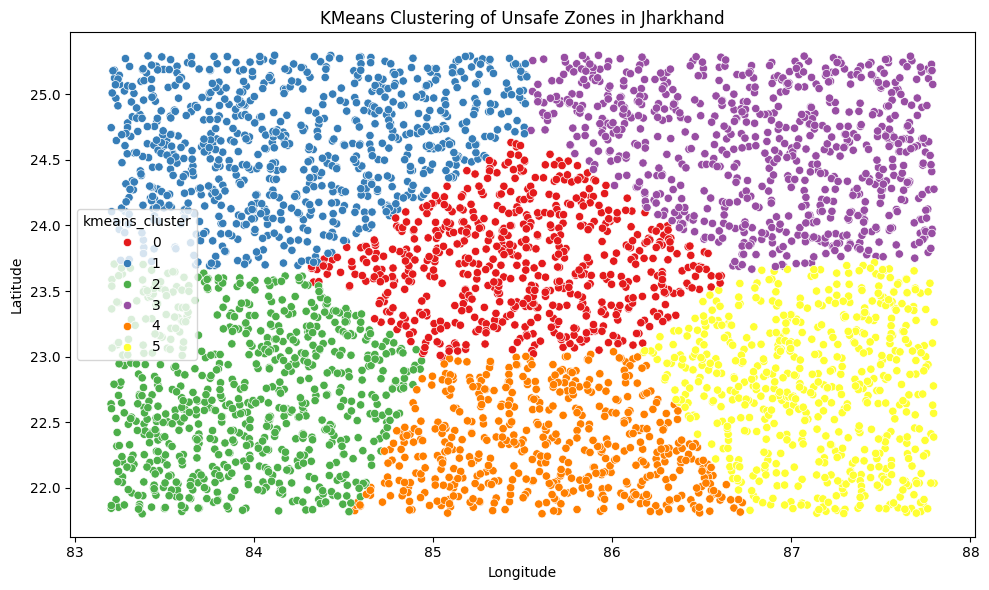

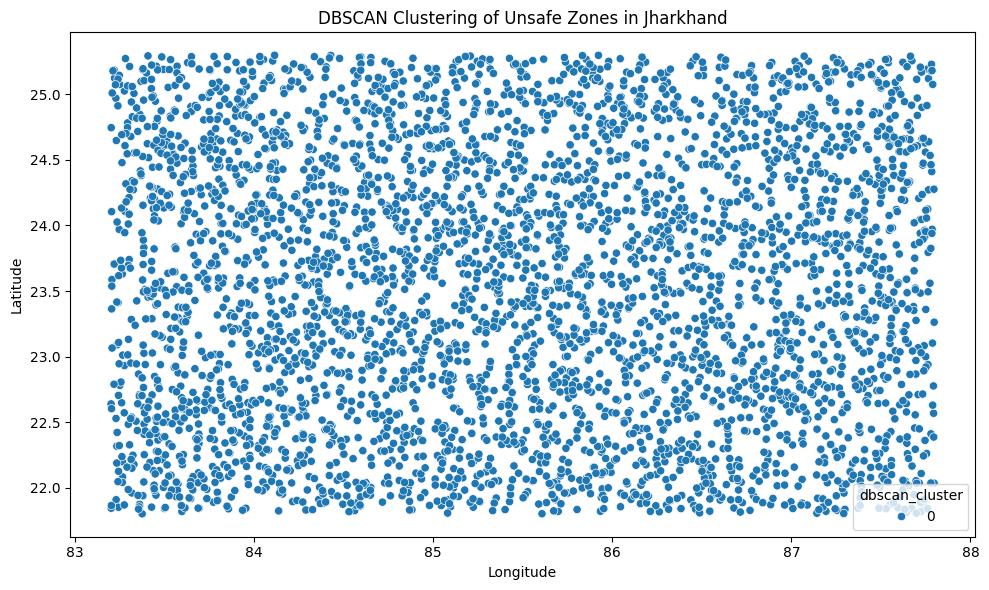

In [21]:
# 8.3: Clustering with KMeans and DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN

# Normalize coordinates for clustering
scaler_coords = StandardScaler()
coords_scaled = scaler_coords.fit_transform(data[['latitude', 'longitude']])

# KMeans clustering
kmeans = KMeans(n_clusters=6, random_state=42)
data['kmeans_cluster'] = kmeans.fit_predict(coords_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['longitude'], y=data['latitude'], hue=data['kmeans_cluster'], palette='Set1')
plt.title('KMeans Clustering of Unsafe Zones in Jharkhand')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('kmeans_clusters.png')

# DBSCAN clustering
dbscan = DBSCAN(eps=0.25, min_samples=10)
data['dbscan_cluster'] = dbscan.fit_predict(coords_scaled)
plt.figure(figsize=(10, 6))
sns.scatterplot(x=data['longitude'], y=data['latitude'], hue=data['dbscan_cluster'], palette='tab10')
plt.title('DBSCAN Clustering of Unsafe Zones in Jharkhand')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('dbscan_clusters.png')

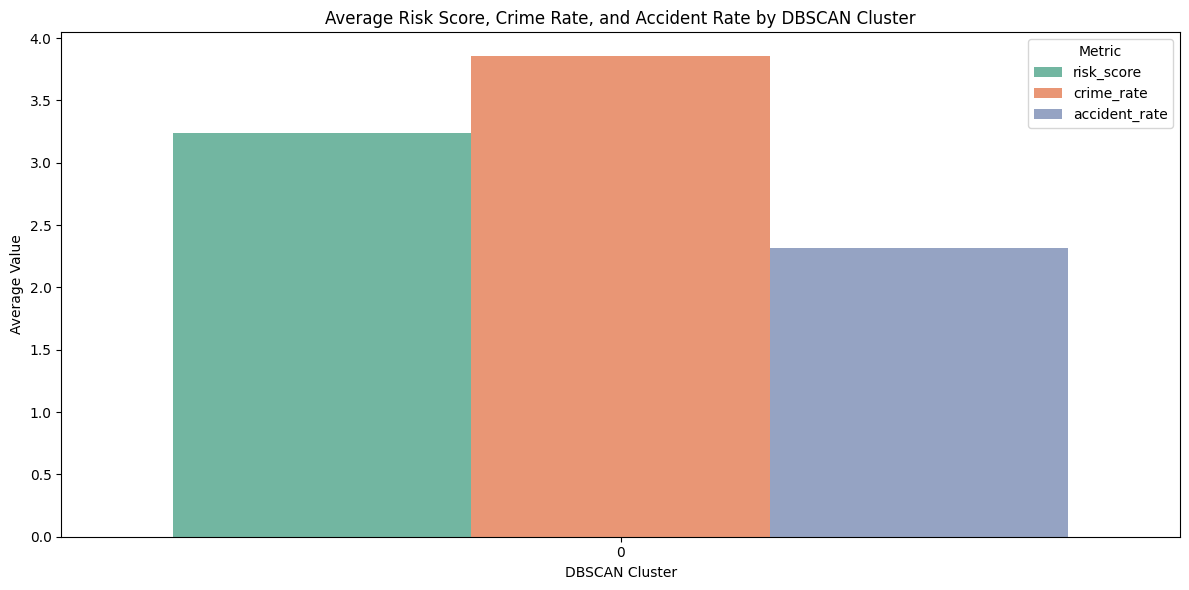

In [22]:
# Step 8.4: Analyze DBSCAN Cluster Characteristics
# Calculate average risk_score, crime_rate, and accident_rate per DBSCAN cluster
dbscan_stats = data.groupby('dbscan_cluster')[['risk_score', 'crime_rate', 'accident_rate']].mean().reset_index()

# Visualize the averages with a grouped bar chart
dbscan_stats_melted = dbscan_stats.melt(id_vars='dbscan_cluster', 
                                        value_vars=['risk_score', 'crime_rate', 'accident_rate'],
                                        var_name='Metric', value_name='Average')
plt.figure(figsize=(12, 6))
sns.barplot(data=dbscan_stats_melted, x='dbscan_cluster', y='Average', hue='Metric', palette='Set2')
plt.title('Average Risk Score, Crime Rate, and Accident Rate by DBSCAN Cluster')
plt.xlabel('DBSCAN Cluster')
plt.ylabel('Average Value')
plt.tight_layout()
plt.savefig('dbscan_cluster_stats.png')

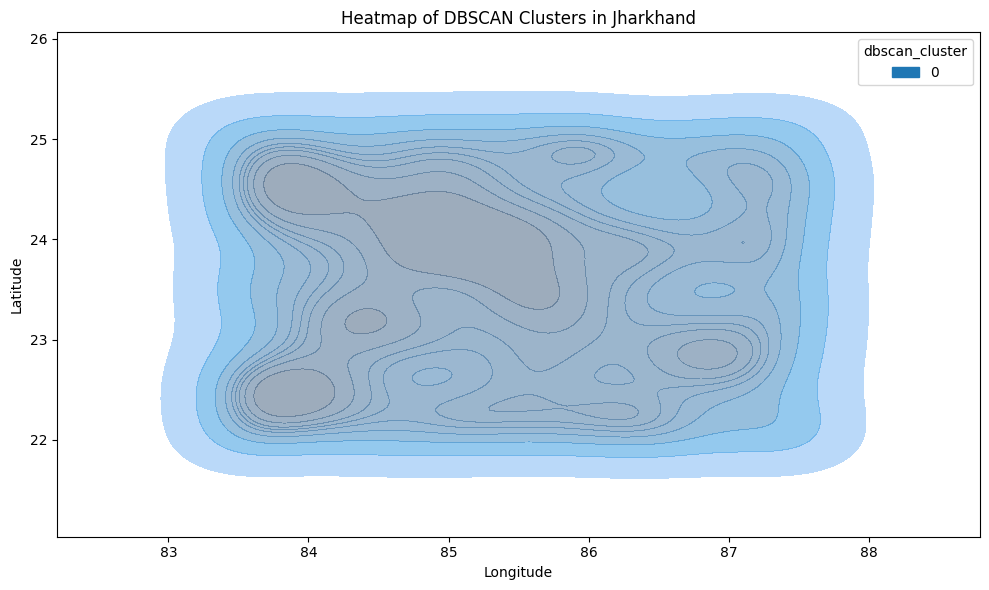

In [23]:
# Step 8.5: Heatmap of DBSCAN Clusters
# Create a heatmap of point density for DBSCAN clusters
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='longitude', y='latitude', hue='dbscan_cluster', palette='tab10', fill=True, alpha=0.5)
plt.title('Heatmap of DBSCAN Clusters in Jharkhand')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.savefig('dbscan_heatmap.png')

In [25]:
# Step 8.6: Model Training for Risk Prediction
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
import joblib
import numpy as np

# Features and targets
features = ['crime_rate', 'accident_rate', 'hour', 'is_night', 'is_lit', 'crowd_density']
target_risk = data['risk_score']
target_class = data['risk_label']

# Split data
X_train, X_test, y_train_r, y_test_r = train_test_split(data[features], target_risk, test_size=0.2, random_state=42)
_, _, y_train_c, y_test_c = train_test_split(data[features], target_class, test_size=0.2, random_state=42)

# Regression: Random Forest
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train, y_train_r)
rf_pred = rf_reg.predict(X_test)
print("Random Forest Regressor Evaluation:")
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, rf_pred)))
print("MAE:", mean_absolute_error(y_test_r, rf_pred))
print("R² Score:", r2_score(y_test_r, rf_pred))

# Regression: XGBoost
xgb_reg = XGBRegressor(random_state=42)
xgb_reg.fit(X_train, y_train_r)
xgb_pred = xgb_reg.predict(X_test)
print("\nXGBoost Regressor Evaluation:")
print("RMSE:", np.sqrt(mean_squared_error(y_test_r, xgb_pred)))
print("MAE:", mean_absolute_error(y_test_r, xgb_pred))
print("R² Score:", r2_score(y_test_r, xgb_pred))

Random Forest Regressor Evaluation:
RMSE: 0.03457786016190349
MAE: 0.02286338821568246
R² Score: 0.9996736562354279

XGBoost Regressor Evaluation:
RMSE: 0.049703900524195016
MAE: 0.03699405637688446
R² Score: 0.9993256893255421


In [26]:
# Classification: Random Forest
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train_c)
rf_clf_pred = rf_clf.predict(X_test)
print("\nRandom Forest Classifier:")
print(classification_report(y_test_c, rf_clf_pred))
print("Accuracy:", accuracy_score(y_test_c, rf_clf_pred))
print("AUC:", roc_auc_score(y_test_c, rf_clf.predict_proba(X_test)[:,1]))

# Classification: XGBoost
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_clf.fit(X_train, y_train_c)
xgb_clf_pred = xgb_clf.predict(X_test)
print("\nXGBoost Classifier:")
print(classification_report(y_test_c, xgb_clf_pred))
print("Accuracy:", accuracy_score(y_test_c, xgb_clf_pred))
print("AUC:", roc_auc_score(y_test_c, xgb_clf.predict_proba(X_test)[:,1]))


Random Forest Classifier:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       545
           1       0.98      0.97      0.98       255

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800

Accuracy: 0.985
AUC: 0.9993344126641481

XGBoost Classifier:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       545
           1       0.98      0.98      0.98       255

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800

Accuracy: 0.9875
AUC: 0.9992588595071057


C:\Users\SWATI KUMARI\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [05:40:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


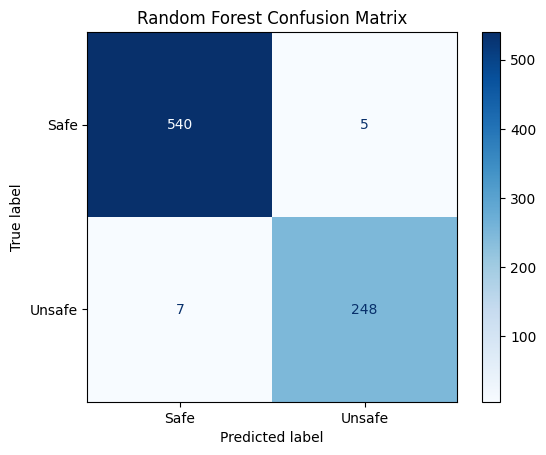

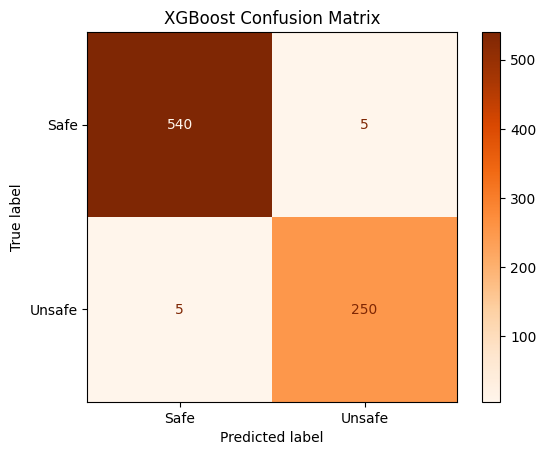

In [28]:
# Confusion matrix for Random Forest Classifier
cm_rf = confusion_matrix(y_test_c, rf_clf_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Safe", "Unsafe"])
disp_rf.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.savefig('rf_confusion_matrix.png')

# Confusion matrix for XGBoost Classifier
cm_xgb = confusion_matrix(y_test_c, xgb_clf_pred)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=["Safe", "Unsafe"])
disp_xgb.plot(cmap="Oranges")
plt.title("XGBoost Confusion Matrix")
plt.savefig('xgb_confusion_matrix.png')



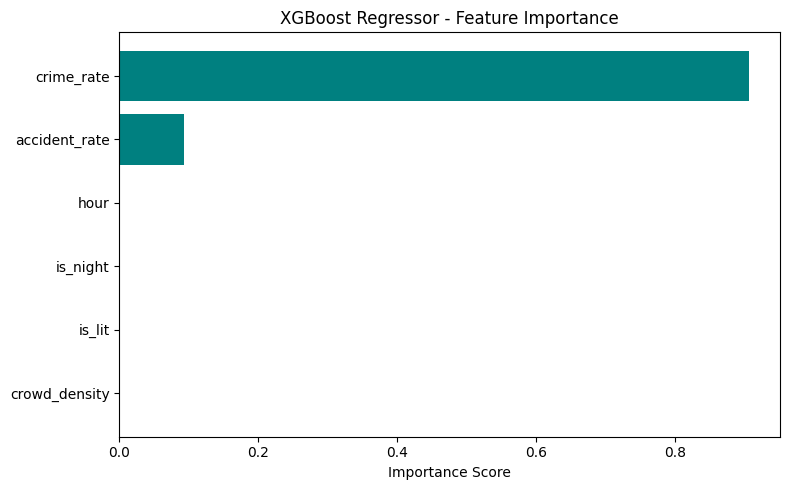

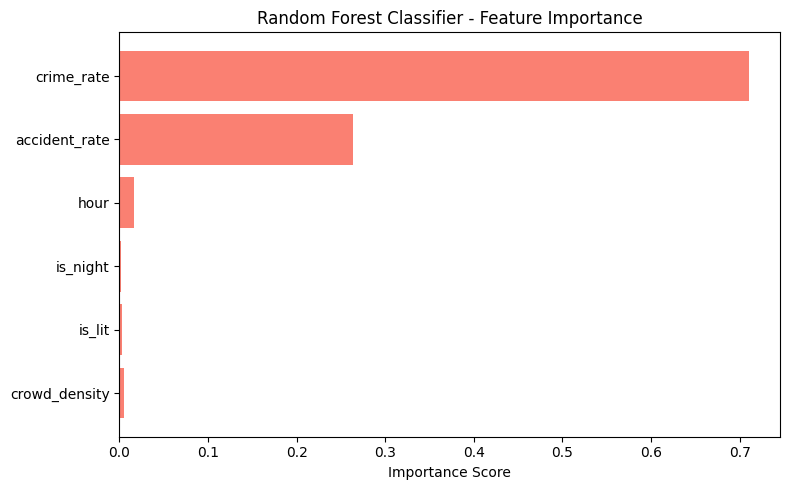

In [29]:
# Feature importance for XGBoost Regressor
plt.figure(figsize=(8, 5))
plt.barh(features, xgb_reg.feature_importances_, color='teal')
plt.xlabel('Importance Score')
plt.title('XGBoost Regressor - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('xgb_feature_importance.png')

# Feature importance for Random Forest Classifier
plt.figure(figsize=(8, 5))
plt.barh(features, rf_clf.feature_importances_, color='salmon')
plt.xlabel('Importance Score')
plt.title('Random Forest Classifier - Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('rf_feature_importance.png')

In [30]:
# Save the models
joblib.dump(xgb_reg, 'xgb_risk_regressor_model.pkl')
joblib.dump(rf_clf, 'rf_risk_classifier_model.pkl')

['rf_risk_classifier_model.pkl']

In [32]:
# Step 8.7: Analyze Classifier Performance on Nighttime vs Daytime Data
# Split test data into nighttime and daytime
X_test_night = X_test[X_test['is_night'] == 1]
y_test_c_night = y_test_c[X_test['is_night'] == 1]
X_test_day = X_test[X_test['is_night'] == 0]
y_test_c_day = y_test_c[X_test['is_night'] == 0]

# Random Forest Classifier performance
rf_night_pred = rf_clf.predict(X_test_night)
rf_night_accuracy = accuracy_score(y_test_c_night, rf_night_pred) if len(y_test_c_night) > 0 else 0
rf_night_auc = roc_auc_score(y_test_c_night, rf_clf.predict_proba(X_test_night)[:,1]) if len(y_test_c_night) > 0 else 0

rf_day_pred = rf_clf.predict(X_test_day)
rf_day_accuracy = accuracy_score(y_test_c_day, rf_day_pred) if len(y_test_c_day) > 0 else 0
rf_day_auc = roc_auc_score(y_test_c_day, rf_clf.predict_proba(X_test_day)[:,1]) if len(y_test_c_day) > 0 else 0

# XGBoost Classifier performance
xgb_night_pred = xgb_clf.predict(X_test_night)
xgb_night_accuracy = accuracy_score(y_test_c_night, xgb_night_pred) if len(y_test_c_night) > 0 else 0
xgb_night_auc = roc_auc_score(y_test_c_night, xgb_clf.predict_proba(X_test_night)[:,1]) if len(y_test_c_night) > 0 else 0

xgb_day_pred = xgb_clf.predict(X_test_day)
xgb_day_accuracy = accuracy_score(y_test_c_day, xgb_day_pred) if len(y_test_c_day) > 0 else 0
xgb_day_auc = roc_auc_score(y_test_c_day, xgb_clf.predict_proba(X_test_day)[:,1]) if len(y_test_c_day) > 0 else 0

# Create a DataFrame for visualization
performance_df = pd.DataFrame({
    'Model': ['Random Forest', 'Random Forest', 'XGBoost', 'XGBoost'],
    'Time': ['Night', 'Day', 'Night', 'Day'],
    'Accuracy': [rf_night_accuracy, rf_day_accuracy, xgb_night_accuracy, xgb_day_accuracy],
    'AUC': [rf_night_auc, rf_day_auc, xgb_night_auc, xgb_day_auc]
})

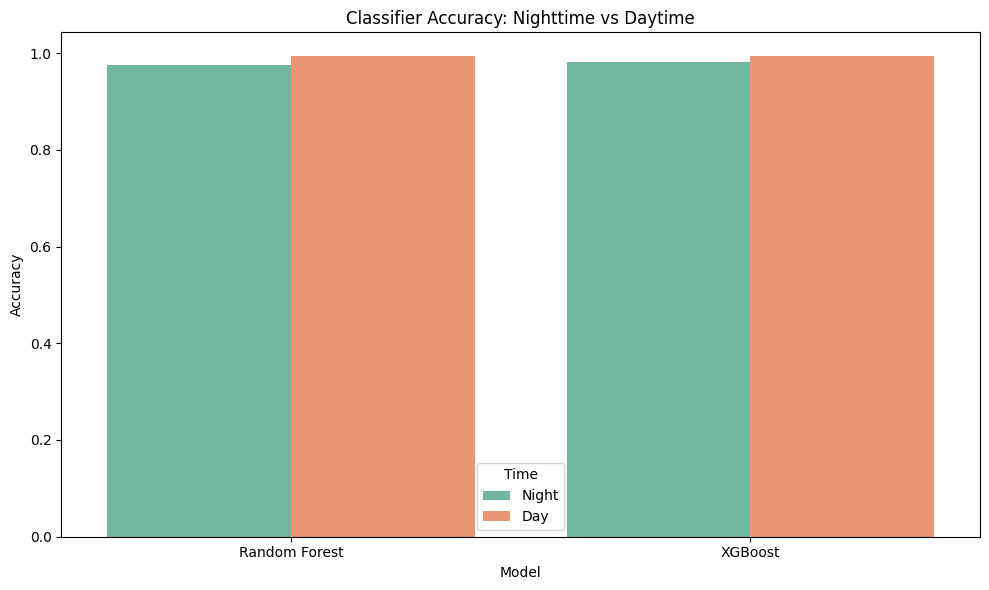

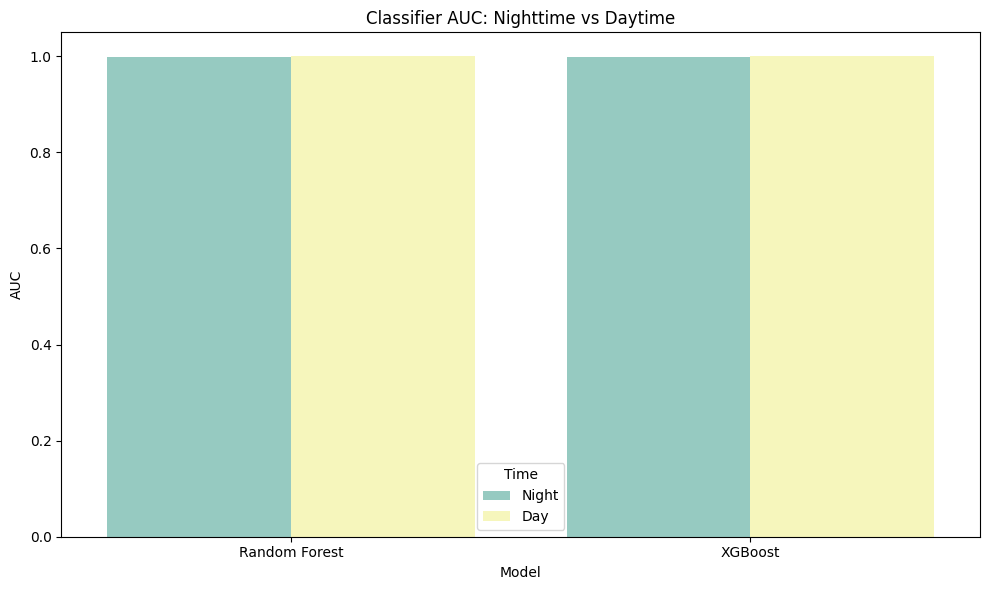

In [33]:
# Visualize Accuracy
plt.figure(figsize=(10, 6))
sns.barplot(data=performance_df, x='Model', y='Accuracy', hue='Time', palette='Set2')
plt.title('Classifier Accuracy: Nighttime vs Daytime')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.savefig('classifier_accuracy_night_day.png')

# Visualize AUC
plt.figure(figsize=(10, 6))
sns.barplot(data=performance_df, x='Model', y='AUC', hue='Time', palette='Set3')
plt.title('Classifier AUC: Nighttime vs Daytime')
plt.xlabel('Model')
plt.ylabel('AUC')
plt.tight_layout()
plt.savefig('classifier_auc_night_day.png')

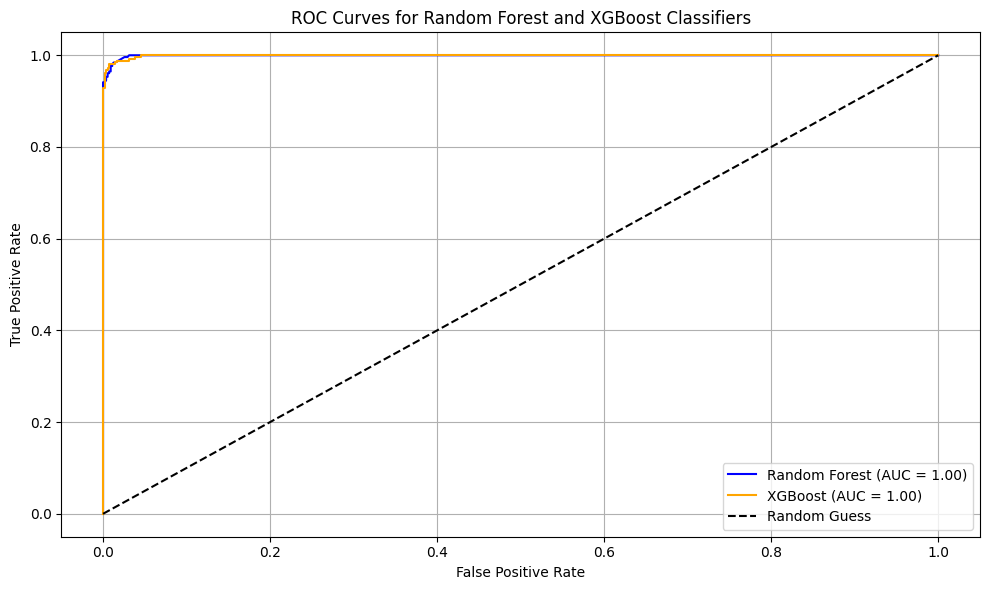

In [34]:
# Step 8.8: Plot ROC Curves for Classifiers
from sklearn.metrics import roc_curve

# ROC Curve for Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test_c, rf_clf.predict_proba(X_test)[:,1])
plt.figure(figsize=(10, 6))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {roc_auc_score(y_test_c, rf_clf.predict_proba(X_test)[:,1]):.2f})', color='blue')

# ROC Curve for XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test_c, xgb_clf.predict_proba(X_test)[:,1])
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test_c, xgb_clf.predict_proba(X_test)[:,1]):.2f})', color='orange')

# Plot settings
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.title('ROC Curves for Random Forest and XGBoost Classifiers')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curves.png')

In [35]:
import joblib
xgb_reg = joblib.load('xgb_risk_regressor_model.pkl')
rf_clf = joblib.load('rf_risk_classifier_model.pkl')
print("Models loaded successfully!")

Models loaded successfully!
